In [1]:
import jax
import jax.numpy as jnp

In [2]:
# Loss function
@jax.jit
def hybrid_segmentation_loss(
    y_pred: jnp.ndarray, 
    y_true: jnp.ndarray, 
    lambda_weight: float = 0.5, 
    smooth: float = 1e-5
) -> jnp.ndarray:
    """Computes the combined stable BCE and Dice Loss for pixel-wise segmentation."""
    # Clip predictions to prevent log(0) errors in BCE
    y_pred_clipped = jnp.clip(y_pred, 1e-7, 1.0 - 1e-7)
    bce = - (y_true * jnp.log(y_pred_clipped) + (1.0 - y_true) * jnp.log(1.0 - y_pred_clipped))
    bce_loss = jnp.mean(bce)
    
    # Calculate spatial Dice Loss across height and width dimensions
    intersection = jnp.sum(y_pred * y_true, axis=(1, 2))
    denominator = jnp.sum(y_pred, axis=(1, 2)) + jnp.sum(y_true, axis=(1, 2))
    dice_coeff = (2.0 * intersection + smooth) / (denominator + smooth)
    dice_loss = jnp.mean(1.0 - dice_coeff)
    
    # Balance both metrics
    return lambda_weight * dice_loss + (1.0 - lambda_weight) * bce_loss

In [4]:
from flax import nnx

In [5]:
grad_fn = nnx.value_and_grad(hybrid_segmentation_loss)

In [6]:
import numpy as np
from PIL import Image

def preprocess_pair(image_path: str, mask_path: str) -> tuple[np.ndarray, np.ndarray]:
    """Resizes and converts raw data pairs into clean training matrices."""
    # Load and scale input image
    img = Image.open(image_path).resize((256, 256))
    img_array = np.array(img, dtype=np.float32) / 255.0
    
    # Load color mask using nearest neighbor to preserve exact colors
    mask = Image.open(mask_path).resize((256, 256), resample=Image.NEAREST)
    mask_array = np.array(mask) 
    
    # Isolate safe zones (e.g., Rangeland where green channel is dominant)
    safe_pixels = (mask_array[..., 1] > 200) & (mask_array[..., 0] < 50) & (mask_array[..., 2] < 50)
    
    # Cast to float32 and add the channel dimension: (256, 256, 1)
    binary_mask = safe_pixels.astype(np.float32)[..., np.newaxis]
    
    return img_array, binary_mask

In [7]:
import random
import jax.numpy as jnp

def batch_generator(samples, batch_size):
    # 🎲 Shuffle paths at the start of each epoch to randomize data
    random.shuffle(samples)
    
    num_samples = len(samples)
    for i in range(0, num_samples, batch_size):
        # Slice the exact chunk of file paths for this batch
        batch_paths = samples[i : i + batch_size]
        
        batch_imgs = []
        batch_masks = []
    
        # Preprocess each individual image-mask pair
        for img_path, mask_path in batch_paths:
            img, mask = preprocess_pair(img_path, mask_path)
            batch_imgs.append(img)
            batch_masks.append(mask)
            
        # Stack the samples into JAX arrays matching (batch_size, 256, 256, C)
        yield jnp.array(batch_imgs), jnp.array(batch_masks)

In [9]:
import os
from google.colab import userdata
from kaggle.api.kaggle_api_extended import KaggleApi

# 1. Provide credentials using Colab Secrets
os.environ["KAGGLE_USERNAME"] = "michaelmukiibi"
os.environ["KAGGLE_KEY"] = "KAGGLE_API_TOKEN=KGAT_b9a2ad9de74894ee148afef27dc7e632"
# 2. Authenticate the SDK
api = KaggleApi()
api.authenticate()

# 3. Pull the Land Cover dataset 
print("Downloading Land Cover dataset...")
api.dataset_download_files(
    'balraj98/deepglobe-land-cover-classification-dataset', 
    path='./deepglobe_land_cover', 
    unzip=True
)
print("Download complete! Files saved to './deepglobe_land_cover'")


Dataset URL: https://www.kaggle.com/datasets/balraj98/deepglobe-land-cover-classification-dataset
Download complete! Files saved to './deepglobe_land_cover'


In [10]:
import glob
import os

def get_dataset_pairs(data_dir="./deepglobe_land_cover/train"):
    # 📁 Find all satellite images and sort them for structural alignment
    sat_paths = sorted(glob.glob(os.path.join(data_dir, "*_sat.jpg")))
    
    pairs = []
    for sat_path in sat_paths:
        # 🧩 Derive the matching mask path by replacing the suffix
        mask_path = sat_path.replace("_sat.jpg", "_mask.png")
        
        # 🛡️ Verify the mask file actually exists before adding it
        if os.path.exists(mask_path):
            pairs.append((sat_path, mask_path))
            
    return pairs

# Generate the complete samples list
samples = get_dataset_pairs()
print(f"Total paired samples found: {len(samples)}")

Total paired samples found: 803


In [14]:
next(iter(samples))

('./deepglobe_land_cover/train/570332_sat.jpg',
 './deepglobe_land_cover/train/570332_mask.png')

In [25]:
import os
import glob
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class DeepGlobeDataset(Dataset):
    def __init__(self, data_dir, csv_file, transform=None):
        """
        Custom Dataset for DeepGlobe. Expects a metadata CSV mapping 'image_id'
        to 'sat_image_path' and 'mask_path'.
        """
        self.data_dir = data_dir
        self.metadata = pd.read_csv(os.path.join(data_dir, csv_file))
        # Filter out rows that do not have valid masks or images
        self.metadata = self.metadata.dropna().reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        # Extract row info
        row = self.metadata.iloc[idx]
        
        # Build full file paths
        img_path = os.path.join(self.data_dir, row['sat_image_path'])
        mask_path = os.path.join(self.data_dir, row['mask_path'])
        
        # Load images (RGB) and masks (RGB or Grayscale depending on preprocessing)
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("RGB")
        
        # Apply standard transformations (e.g., resizing, tensor conversion)
        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
            
        return image, mask

# --- Pipeline Configuration ---

# Path pointing to your Google Drive setup from the previous step
DATA_DIR = './deepglobe_land_cover'
# The DeepGlobe dataset includes metadata CSV files (e.g., 'metadata.csv')
CSV_FILE = 'metadata.csv' 

# Standard transforms for deep learning models (Resizing reduces memory load in Colab)
data_transforms = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

# Initialize Dataset and DataLoader
dataset = DeepGlobeDataset(data_dir=DATA_DIR, csv_file=CSV_FILE, transform=data_transforms)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print(f"Dataset successfully initialized with {len(dataset)} image pairs.")


Dataset successfully initialized with 803 image pairs.


Images batch shape: torch.Size([4, 3, 512, 512])
Masks batch shape: torch.Size([4, 3, 512, 512])


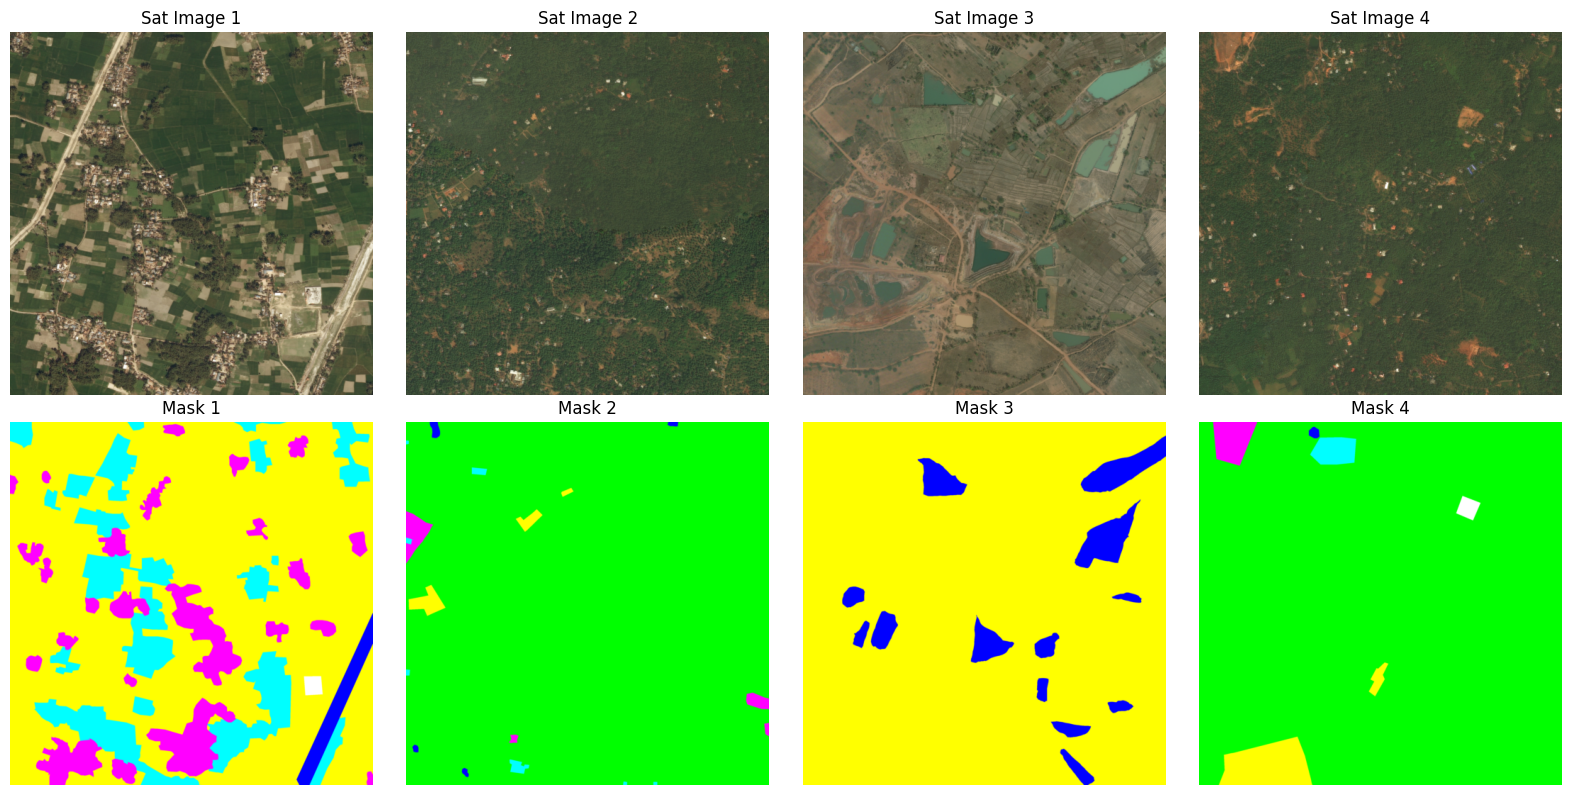

In [21]:
# Grab one batch from your loader
images_batch, masks_batch = next(iter(dataloader))

print(f"Images batch shape: {images_batch.shape}") # Expecting [batch_size, 3, 512, 512]
print(f"Masks batch shape: {masks_batch.shape}")

# Plotting function
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))

for i in range(4):
    # Convert PyTorch tensors back to viewable image arrays
    sat_img = images_batch[i].permute(1, 2, 0).numpy()
    mask_img = masks_batch[i].permute(1, 2, 0).numpy()
    
    # Row 0: Satellite Images
    axes[0, i].imshow(sat_img)
    axes[0, i].set_title(f"Sat Image {i+1}")
    axes[0, i].axis('off')
    
    # Row 1: Corresponding Target Masks
    axes[1, i].imshow(mask_img)
    axes[1, i].set_title(f"Mask {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [10]:
# 📦 Instantiate our generator with a batch size of 16
train_gen = batch_generator(samples, batch_size=16)

# ⏭️ Grab the first batch manually
img_batch, mask_batch = next(train_gen)

print("Images shape:", img_batch.shape)
print("Masks shape:", mask_batch.shape)

Images shape: (16, 256, 256, 3)
Masks shape: (16, 256, 256, 1)


In [14]:
from flax import nnx
import jax.numpy as jnp

class TinyUNet(nnx.Module):
    def __init__(self, rngs: nnx.Rngs):
        # Encoder layers: channels increase
        self.enc_conv = nnx.Conv(3, 32, kernel_size=(3, 3), padding="SAME", rngs=rngs)
        self.pool = lambda x: nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        self.bottleneck = nnx.Conv(32, 64, kernel_size=(3, 3), padding="SAME", rngs=rngs)
        
        # Decoder layers: channels decrease after skip connection concatenation
        self.upsample = nnx.ConvTranspose(64, 32, kernel_size=(2, 2), strides=(2, 2), rngs=rngs)
        self.dec_conv = nnx.Conv(64, 1, kernel_size=(3, 3), padding="SAME", rngs=rngs)

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        # 📉 Encoder path
        x_skip = nnx.relu(self.enc_conv(x))       # Shape: (B, 256, 256, 32)
        x_pooled = self.pool(x_skip)              # Shape: (B, 128, 128, 32)
        
        # 🎯 Bottleneck
        x_mid = nnx.relu(self.bottleneck(x_pooled)) # Shape: (B, 128, 128, 64)
        
        # 📈 Decoder path with skip connection
        x_up = self.upsample(x_mid)               # Shape: (B, 256, 256, 32)
        x_cat = jnp.concatenate([x_up, x_skip], axis=-1) # Shape: (B, 256, 256, 64)
        
        # 🏁 Final binary logit projection
        return self.dec_conv(x_cat)               # Shape: (B, 256, 256, 1)

In [15]:
@nnx.jit
def train_step(model: TinyUNet, optimizer: nnx.Optimizer, batch):
    images, masks = batch
    
    # 📉 Define the loss function for differentiation
    def loss_fn(model):
        # Calculate predictions here
        logits = model(images) 
        loss = hybrid_segmentation_loss(logits, masks)
        return loss
    
    # 🧮 Compute loss and gradients simultaneously
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    
    # 🔄 Update the network parameters
    optimizer.update(model, grads)
    
    return loss

In [16]:
from google.colab import drive
import os

# 1. 🗂️ Mount Google Drive to the Colab runtime
drive.mount('/content/drive')

# 2. 📁 Define the destination path on your Drive
drive_dest = "/content/drive/MyDrive/deepglobe_land_cover"

# 3. ⚡ Copy the entire folder recursively
print("Transferring dataset to Google Drive... This can take a few minutes.")
!cp -r ./deepglobe_land_cover "$drive_dest"
print("Transfer complete! Files are safely stored on your Google Drive.")

Mounted at /content/drive
Transferring dataset to Google Drive... This can take a few minutes.
Transfer complete! Files are safely stored on your Google Drive.


In [28]:
import wandb

In [30]:
wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: michaelmukiibi (growsafe) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [31]:
import time
import jax.numpy as jnp
import optax
from flax import nnx
import wandb

# Initialize Weights & Biases run
wandb.init(
    project="drone-landing-safety",
    config={
        "learning_rate": 1e-3,
        "epochs": 5,
        "batch_size": 4,
        "architecture": "TinyUNet"
    }
)

# 1. Initialize model and optimizer states
rngs = nnx.Rngs(42)
model = TinyUNet(rngs=rngs)
optimizer = nnx.Optimizer(model, optax.adam(learning_rate=1e-3), wrt=nnx.Param)

# 2. Run the verbose training loop with W&B tracking
num_epochs = 5
print("Launching training loop with real-time logging and W&B tracking...")

for epoch in range(num_epochs):
    epoch_loss = 0.0
    steps = 0
    epoch_start_time = time.time()
    
    for torch_images, torch_masks in dataloader:
        step_start_time = time.time()
        
        # Convert PyTorch tensors to JAX arrays and change memory layout
        images = jnp.array(torch_images.numpy().transpose(0, 2, 3, 1))
        masks = jnp.array(torch_masks.numpy().transpose(0, 2, 3, 1))[..., :1]
        
        # Execute the JIT-compiled update step
        loss = train_step(model, optimizer, (images, masks))
        loss_val = float(loss)
        
        epoch_loss += loss_val
        steps += 1
        step_duration = time.time() - step_start_time
        
        # Log metrics to Weights & Biases at every step
        wandb.log({
            "batch_loss": loss_val,
            "step_duration_sec": step_duration,
            "epoch": epoch + 1
        })
        
        # Print metrics every 10 batches (and the very first batch)
        if steps == 1 or steps % 10 == 0:
            print(f"Epoch {epoch + 1}/{num_epochs} | Step {steps:03d} | "
                  f"Current Loss: {loss_val:.4f} | Speed: {step_duration:.3f}s/batch")
        
    # Epoch summary
    avg_loss = epoch_loss / steps
    epoch_duration = time.time() - epoch_start_time
    
    # Log epoch-level summary statistics
    wandb.log({
        "epoch_avg_loss": avg_loss,
        "epoch_duration_sec": epoch_duration
    })
    
    print(f"Epoch {epoch + 1} Done -> Average Loss: {avg_loss:.4f} | "
          f"Total Epoch Time: {epoch_duration:.2f}s\n" + "-"*60)

# Close the W&B run safely
wandb.finish()

Launching training loop with real-time logging and W&B tracking...
Epoch 1/5 | Step 001 | Current Loss: 5.6317 | Speed: 2.528s/batch
Epoch 1/5 | Step 010 | Current Loss: 0.6200 | Speed: 1.389s/batch
Epoch 1/5 | Step 020 | Current Loss: 1.0136 | Speed: 1.281s/batch
Epoch 1 Done -> Average Loss: 1.0903 | Total Epoch Time: 203.57s
------------------------------------------------------------
Epoch 2/5 | Step 001 | Current Loss: 0.5283 | Speed: 1.403s/batch
Epoch 2/5 | Step 010 | Current Loss: 0.5892 | Speed: 1.372s/batch
Epoch 2/5 | Step 020 | Current Loss: 0.5654 | Speed: 1.231s/batch
Epoch 2 Done -> Average Loss: 0.5517 | Total Epoch Time: 200.73s
------------------------------------------------------------
Epoch 3/5 | Step 001 | Current Loss: 0.5323 | Speed: 1.411s/batch
Epoch 3/5 | Step 010 | Current Loss: 0.4243 | Speed: 1.360s/batch


: 

In [ ]:
import time
import jax.numpy as jnp
import optax
from flax import nnx

# 1. Initialize model and optimizer states
rngs = nnx.Rngs(42)
model = TinyUNet(rngs=rngs)
optimizer = nnx.Optimizer(model, optax.adam(learning_rate=1e-3), wrt=nnx.Param)

# 2. Run the verbose training loop
num_epochs = 5
print("Launching training loop with real-time logging...")

for epoch in range(num_epochs):
    epoch_loss = 0.0
    steps = 0
    epoch_start_time = time.time()
    
    for torch_images, torch_masks in dataloader:
        step_start_time = time.time()
        
        # Convert PyTorch tensors to JAX arrays and change memory layout
        images = jnp.array(torch_images.numpy().transpose(0, 2, 3, 1))
        masks = jnp.array(torch_masks.numpy().transpose(0, 2, 3, 1))[..., :1]
        
        # Execute the JIT-compiled update step
        loss = train_step(model, optimizer, (images, masks))
        
        epoch_loss += float(loss)
        steps += 1
        step_duration = time.time() - step_start_time
        
        # Print metrics every 10 batches (and the very first batch)
        if steps == 1 or steps % 10 == 0:
            print(f"Epoch {epoch + 1}/{num_epochs} | Step {steps:03d} | "
                  f"Current Loss: {float(loss):.4f} | Speed: {step_duration:.3f}s/batch")
        
    # Epoch summary
    avg_loss = epoch_loss / steps
    epoch_duration = time.time() - epoch_start_time
    print(f"Epoch {epoch + 1} Done -> Average Loss: {avg_loss:.4f} | "
          f"Total Epoch Time: {epoch_duration:.2f}s\n" + "-"*60)